In [1]:
import pymysql
import os
import pandas as pd
import datetime as dt
import pytz
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import entropy


pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [2]:
#Connection to  MySQL server, parameters must be filled with correct information otherwise it won't work
conn = pymysql.connect(
    host = '127.0.0.1',
    user = 'root',
    password =  os.getenv("PASSWORD_MY_SQL"),
    database = 'data'
    )
cursor = conn.cursor()

# Preparing all addresses

In [3]:
#Extracting addresses with assigned timezone
sql = """SELECT eh.entity, eh.address, sd.timezone, sd.offsset, sd.is_regional_location FROM entities_heur as eh
    LEFT JOIN scraped_data as sd ON eh.entity = sd.entity
    LEFT JOIN exchanges_detection as ed on sd.id = ed.id
    WHERE sd.address is not null 
        and sd.location is not null 
        and sd.num_txs > 0 
        and sd.timezone is not null 
        and ed.arkham_entity is null 
        and (ed.arkham_label is null or ed.arkham_label = "Miner");"""
cursor.execute(sql)
data = cursor.fetchall()
len(data)

130214

In [4]:
data = pd.DataFrame(data, columns = ["entity", "address", "timezone", "offset", "is_regional_location"])
data.head()

,entity,address,timezone,offset,is_regional_location
0,Entity 2436,121iyz8ZHtSNHX3mVTHzxztQ33cueBVEu5,Europe/Stockholm,1.0,0
1,Entity 2436,12418afg3GhCD56oHS5j9f2GzbcbP5oHjY,Europe/Stockholm,1.0,0
2,Entity 2436,12BmH6NTySEgudTSCYUbPtbn3tLtYyeWYg,Europe/Stockholm,1.0,0
3,Entity 2436,12DwYSkSw5H6twHcvGDu2tu3ZakdTFShB2,Europe/Stockholm,1.0,0
4,Entity 2436,12GmdvZKwPpdfRumDakRgJg2rcUG9T3inQ,Europe/Stockholm,1.0,0


In [5]:
distinct_entities = data["entity"].unique()
distinct_entities = pd.DataFrame(distinct_entities, columns = ["entity"])
distinct_entities.head()
len(distinct_entities)

5064

In [6]:
# Entities, in which happened that in one cluster there is more entities
sql_query = """
        SELECT DISTINCT entity 
        FROM entities_heur 
        WHERE address IN (
            SELECT address 
            FROM entities_heur 
            GROUP BY address 
            HAVING COUNT(entity) > 1
        );
        """
cursor.execute(sql_query)
entities_in_one_cluster = cursor.fetchall()
entities_in_one_cluster = pd.DataFrame(entities_in_one_cluster, columns = ["entity"])
len(entities_in_one_cluster)

215

In [7]:
# Total number of such clusters
# 1. Get the addresses and their overlapping entities
sql_query = """
SELECT address, entity 
FROM entities_heur 
WHERE address IN (
    SELECT address 
    FROM entities_heur 
    GROUP BY address 
    HAVING COUNT(entity) > 1
);
"""
cursor.execute(sql_query)
overlapping_records = cursor.fetchall()

# Group entities by address using tuple indices
address_to_entities = {}
for row in overlapping_records:
    addr = row[0]  # SELECT address (Index 0)
    ent = row[1]   # SELECT entity (Index 1)
    
    if addr not in address_to_entities:
        address_to_entities[addr] = set()
    address_to_entities[addr].add(ent)

# Get unique groups of entities
unique_entity_groups = []
seen_groups = set()
for entities in address_to_entities.values():
    sorted_tuple = tuple(sorted(entities))
    if sorted_tuple not in seen_groups:
        seen_groups.add(sorted_tuple)
        unique_entity_groups.append(list(sorted_tuple))

# 2. Extract flat list of entities and fetch their timezones
all_entities = list(set(entity for group in unique_entity_groups for entity in group))

placeholders = ', '.join(['%s'] * len(all_entities))
tz_query = f"""
SELECT entity, timezone 
FROM scraped_data 
WHERE entity IN ({placeholders})
"""
cursor.execute(tz_query, all_entities)
tz_records = cursor.fetchall()

# Map entities to timezones using tuple indices
entity_tz_map = {row[0]: row[1] for row in tz_records} # row[0] is entity, row[1] is timezone

# 3. Compare timezones within each group
matching_groups = []
mismatching_groups = []

for group in unique_entity_groups:
    group_timezones = set()
    for entity in group:
        tz = entity_tz_map.get(entity, "Unknown") 
        group_timezones.add(tz)

    if len(group_timezones) == 1:
        matching_groups.append({
            "entities": group, 
            "timezone": list(group_timezones)[0]
        })
    else:
        mismatching_groups.append({
            "entities": group, 
            "timezones": list(group_timezones)
        })



print(f"Groups with the SAME timezone: {len(matching_groups)}")
for mg in matching_groups: 
    print(mg)

print(f"\nGroups with DIFFERENT timezones (Temporal Drift / Noise): {len(mismatching_groups)}")
for mmg in mismatching_groups: 
    print(mmg)

Groups with the SAME timezone: 81
{'entities': ['Entity 10068', 'Entity 2265'], 'timezone': 'Europe/Paris'}
{'entities': ['Entity 1019', 'Entity 6499'], 'timezone': 'Europe/London'}
{'entities': ['Entity 1029', 'Entity 16764'], 'timezone': 'Asia/Kolkata'}
{'entities': ['Entity 1036', 'Entity 23080'], 'timezone': 'Asia/Kolkata'}
{'entities': ['Entity 10447', 'Entity 1659'], 'timezone': 'Asia/Kolkata'}
{'entities': ['Entity 10797', 'Entity 788'], 'timezone': 'Asia/Shanghai'}
{'entities': ['Entity 10902', 'Entity 4265'], 'timezone': 'Asia/Bangkok'}
{'entities': ['Entity 11098', 'Entity 2641'], 'timezone': 'Asia/Kolkata'}
{'entities': ['Entity 11116', 'Entity 1394'], 'timezone': 'Asia/Jakarta'}
{'entities': ['Entity 114', 'Entity 8749'], 'timezone': 'Europe/London'}
{'entities': ['Entity 1157', 'Entity 14659'], 'timezone': 'Asia/Shanghai'}
{'entities': ['Entity 11783', 'Entity 12020', 'Entity 12028', 'Entity 12050', 'Entity 12332', 'Entity 12758', 'Entity 13097', 'Entity 13212', 'Entity 14

In [8]:
# Assuming your list of dictionaries is named 'matching_groups'
entities_to_exclude = []

for group in matching_groups:
    # Slice the list from index 1 to the end to grab everything EXCEPT the first entity
    entities_to_exclude.extend(group['entities'][1:])

print(entities_to_exclude)
len(entities_to_exclude)

['Entity 2265', 'Entity 6499', 'Entity 16764', 'Entity 23080', 'Entity 1659', 'Entity 788', 'Entity 4265', 'Entity 2641', 'Entity 1394', 'Entity 8749', 'Entity 14659', 'Entity 12020', 'Entity 12028', 'Entity 12050', 'Entity 12332', 'Entity 12758', 'Entity 13097', 'Entity 13212', 'Entity 14354', 'Entity 14525', 'Entity 14660', 'Entity 3692', 'Entity 15496', 'Entity 12696', 'Entity 12811', 'Entity 20318', 'Entity 15524', 'Entity 1681', 'Entity 14140', 'Entity 245', 'Entity 450', 'Entity 880', 'Entity 558', 'Entity 611', 'Entity 19870', 'Entity 19790', 'Entity 21052', 'Entity 484', 'Entity 2930', 'Entity 1749', 'Entity 9653', 'Entity 4180', 'Entity 1715', 'Entity 3785', 'Entity 20105', 'Entity 20589', 'Entity 2475', 'Entity 3074', 'Entity 696', 'Entity 950', 'Entity 274', 'Entity 21933', 'Entity 2429', 'Entity 2671', 'Entity 2216', 'Entity 3712', 'Entity 84', 'Entity 379', 'Entity 54', 'Entity 4193', 'Entity 386', 'Entity 854', 'Entity 2332', 'Entity 21594', 'Entity 21718', 'Entity 21723'

99

In [9]:
list_of_included_entities = ["Entity 24969", "Entity 25189", "Entity 2569", "Entity 29162", "Entity 332"]
for group in mismatching_groups:
    # Slice the list from index 1 to the end to grab everything EXCEPT the first entity
    entities_to_exclude.extend(group['entities'])

print(entities_to_exclude)
len(entities_to_exclude)

['Entity 2265', 'Entity 6499', 'Entity 16764', 'Entity 23080', 'Entity 1659', 'Entity 788', 'Entity 4265', 'Entity 2641', 'Entity 1394', 'Entity 8749', 'Entity 14659', 'Entity 12020', 'Entity 12028', 'Entity 12050', 'Entity 12332', 'Entity 12758', 'Entity 13097', 'Entity 13212', 'Entity 14354', 'Entity 14525', 'Entity 14660', 'Entity 3692', 'Entity 15496', 'Entity 12696', 'Entity 12811', 'Entity 20318', 'Entity 15524', 'Entity 1681', 'Entity 14140', 'Entity 245', 'Entity 450', 'Entity 880', 'Entity 558', 'Entity 611', 'Entity 19870', 'Entity 19790', 'Entity 21052', 'Entity 484', 'Entity 2930', 'Entity 1749', 'Entity 9653', 'Entity 4180', 'Entity 1715', 'Entity 3785', 'Entity 20105', 'Entity 20589', 'Entity 2475', 'Entity 3074', 'Entity 696', 'Entity 950', 'Entity 274', 'Entity 21933', 'Entity 2429', 'Entity 2671', 'Entity 2216', 'Entity 3712', 'Entity 84', 'Entity 379', 'Entity 54', 'Entity 4193', 'Entity 386', 'Entity 854', 'Entity 2332', 'Entity 21594', 'Entity 21718', 'Entity 21723'

134

In [10]:
# Converts to sets, subtracts, and converts back to a list
entities_to_exclude = list(set(entities_to_exclude) - set(list_of_included_entities))
print(entities_to_exclude)
len(entities_to_exclude)

['Entity 397', 'Entity 12758', 'Entity 696', 'Entity 2940', 'Entity 3167', 'Entity 472', 'Entity 19870', 'Entity 12332', 'Entity 20105', 'Entity 9035', 'Entity 12811', 'Entity 2671', 'Entity 3800', 'Entity 8702', 'Entity 21594', 'Entity 1749', 'Entity 564', 'Entity 24375', 'Entity 20318', 'Entity 21718', 'Entity 30020', 'Entity 25086', 'Entity 25802', 'Entity 11373', 'Entity 3785', 'Entity 14354', 'Entity 29457', 'Entity 1681', 'Entity 2265', 'Entity 54', 'Entity 19790', 'Entity 8749', 'Entity 26264', 'Entity 3357', 'Entity 379', 'Entity 453', 'Entity 14140', 'Entity 22260', 'Entity 3640', 'Entity 1394', 'Entity 713', 'Entity 254', 'Entity 6995', 'Entity 13097', 'Entity 2429', 'Entity 97', 'Entity 2930', 'Entity 2475', 'Entity 7650', 'Entity 23080', 'Entity 558', 'Entity 633', 'Entity 10632', 'Entity 2216', 'Entity 2162', 'Entity 21380', 'Entity 1659', 'Entity 8111', 'Entity 14660', 'Entity 3712', 'Entity 9516', 'Entity 15524', 'Entity 2332', 'Entity 2165', 'Entity 108', 'Entity 8003',

129

In [11]:
data = data[~data["entity"].isin(entities_to_exclude)]
print(len(data[["entity", "timezone", "is_regional_location"]].drop_duplicates()[data["is_regional_location"] == 1]))
data[["entity", "timezone", "is_regional_location"]].drop_duplicates()[data["is_regional_location"] == 0].head()

625


/tmp/ipykernel_15374/141321484.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(len(data[["entity", "timezone", "is_regional_location"]].drop_duplicates()[data["is_regional_location"] == 1]))
/tmp/ipykernel_15374/141321484.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data[["entity", "timezone", "is_regional_location"]].drop_duplicates()[data["is_regional_location"] == 0].head()


,entity,timezone,is_regional_location
0,Entity 2436,Europe/Stockholm,0
144,Entity 1827,Europe/London,0
158,Entity 2497,Europe/Amsterdam,0
528,Entity 3139,Europe/Helsinki,0
946,Entity 249,Europe/Paris,0


In [12]:
data = data[~data["offset"].isna()]
len(data)

111970

In [13]:
#Transforming address to list and deleting duplicates
addresses = data["address"]
addresses = addresses.drop_duplicates()
addresses = addresses.tolist()

# Getting transaction data

In [14]:
#Getting all outgoing transaction to addresses from list
placeholders = ','.join(['%s'] * len(addresses))

query = f"""SELECT DISTINCT ti.txid, ti.input_order, ti.address, bd.mempool_entry_time, bd.fee, bd.num_inputs, bd.num_outputs, ti.value FROM tx_inputs AS ti
LEFT JOIN blockchain_data AS bd on ti.txid = bd.txid
WHERE address in ({placeholders});"""

cursor.execute(query, addresses)
database = cursor.fetchall()
database = pd.DataFrame(database, columns = ["txid", "input_order", "address", "mempool_entry_time", "fee", "num_inputs", "num_outputs", "value"])
database.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605
1,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.298024
2,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,1,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.158314
3,00007bf94d53e5a2cfb4d7aa94039553fadd80f85b9b5eca57de2bd986d56e2e,0,188FPxXv1i4d9F7jQUYUf1Zt2RTh7RnFCG,2016-05-15 20:19:07,34.793774,1,2,0.285407
4,0000a1407c1f573268ea82a20305ed68294351a1f665d08544c3900987df3c43,0,1NissionTGS4S8DvNmGf13amLQuWUZM1nd,2017-08-17 00:59:42,389.105058,1,2,0.107424


In [15]:
#Merging transaction data to addresses to obtain entity identification number
db_final = database.merge(
    data,
    how = "left",
    on = "address"
)
db_final.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset,is_regional_location
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605,Entity 1861,Europe/Copenhagen,1.0,0
1,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.298024,Entity 505,Asia/Manila,8.0,0
2,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,1,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.158314,Entity 505,Asia/Manila,8.0,0
3,00007bf94d53e5a2cfb4d7aa94039553fadd80f85b9b5eca57de2bd986d56e2e,0,188FPxXv1i4d9F7jQUYUf1Zt2RTh7RnFCG,2016-05-15 20:19:07,34.793774,1,2,0.285407,Entity 70,Europe/Kyiv,2.0,0
4,0000a1407c1f573268ea82a20305ed68294351a1f665d08544c3900987df3c43,0,1NissionTGS4S8DvNmGf13amLQuWUZM1nd,2017-08-17 00:59:42,389.105058,1,2,0.107424,Entity 2090,Asia/Tokyo,9.0,0


In [16]:
#Creating help variable with adjusted time to UTC +0:00
db_final["time_adjusted"] = db_final.apply(
    lambda r: r["mempool_entry_time"] + pd.Timedelta(hours = r["offset"]),
    axis = 1
)
db_final = db_final.drop_duplicates(subset = ["txid"])
db_final.head()

/tmp/ipykernel_15374/37489651.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  lambda r: r["mempool_entry_time"] + pd.Timedelta(hours = r["offset"]),


,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset,is_regional_location,time_adjusted
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605,Entity 1861,Europe/Copenhagen,1.0,0,2020-09-06 04:41:07
1,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.298024,Entity 505,Asia/Manila,8.0,0,2015-11-26 21:20:49
3,00007bf94d53e5a2cfb4d7aa94039553fadd80f85b9b5eca57de2bd986d56e2e,0,188FPxXv1i4d9F7jQUYUf1Zt2RTh7RnFCG,2016-05-15 20:19:07,34.793774,1,2,0.285407,Entity 70,Europe/Kyiv,2.0,0,2016-05-15 22:19:07
4,0000a1407c1f573268ea82a20305ed68294351a1f665d08544c3900987df3c43,0,1NissionTGS4S8DvNmGf13amLQuWUZM1nd,2017-08-17 00:59:42,389.105058,1,2,0.107424,Entity 2090,Asia/Tokyo,9.0,0,2017-08-17 09:59:42
5,0000dec5df278bdb99d2c1763ddbfe93114651e2d87269a1d6ee3065682da921,0,36mskh4wzSgYCXUNae61VF98HrXrjGYdRr,2016-07-27 19:45:25,149.700599,1,2,53.317689,Entity 106,Europe/Stockholm,1.0,0,2016-07-27 20:45:25


In [17]:
len(db_final)

312594

In [18]:
db_final[db_final["mempool_entry_time"] >= "2022-02-27 21:09:19"].head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset,is_regional_location,time_adjusted
116,000dfdb43f35a86eebf5049d4a3619b983170bff4939e3fc34e2f1d40b15b509,0,bc1p8pxnpc8vpgzttxg8eqz3c6dsde5w5pghpwqql47swtwfqtcray0qxnp0ru,2026-06-26 02:27:05,3.228365,3,3,0.028409,Entity 2057,Europe/London,0.0,0,2026-06-26 02:27:05
180,00164d4ee62e431220e1896b0c10a878980a385282040634bb8e97a34c702af4,0,1ALEX2m6HHHrZQa5WV7xgDSMDMFs2m2SWX,2023-03-09 07:45:39,11.417323,1,2,0.854423,Entity 7692,America/Toronto,-5.0,1,2023-03-09 02:45:39
223,00199e8085e1d4a3349f2fafc60dbab9cd34b48e62f080eb6e88849b6918dba5,0,1GxAQsMTJf79Pxy7n3LTfZTDoJnhSYJ2FX,2023-11-02 00:39:02,10.055118,1,2,0.011367,Entity 4766,Australia/Melbourne,11.0,1,2023-11-02 11:39:02
241,001caadfc549493dc4a88541940627a711da930b53607b6473612299d76d15b7,0,15X6dXyBBhEAUnzzuSKbRjCVhXG5jGpRSv,2022-03-31 15:14:19,9.696237,2,2,0.046754,Entity 661,Europe/Moscow,3.0,0,2022-03-31 18:14:19
343,002247ed71040442bcdf7d1f88c8d6266073f4accfd63ca0ad70bd8f9817882c,0,bc1qtuy8xfnap6l92288zmvgdmea2qmcm8x4v3cqek,2026-07-19 18:20:13,3.406475,1,3,0.010939,Entity 2057,Europe/London,0.0,0,2026-07-19 18:20:13


In [19]:
len(db_final[db_final["mempool_entry_time"] >= "2022-02-27 21:09:19"])

12715

In [20]:
num_distinct_entities = db_final["entity"].nunique()
print(num_distinct_entities)

4680


In [23]:
len(db_final[["entity", "is_regional_location"]].drop_duplicates()[db_final["is_regional_location"] == 1])

/tmp/ipykernel_15374/417444719.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(db_final[["entity", "is_regional_location"]].drop_duplicates()[db_final["is_regional_location"] == 1])


587

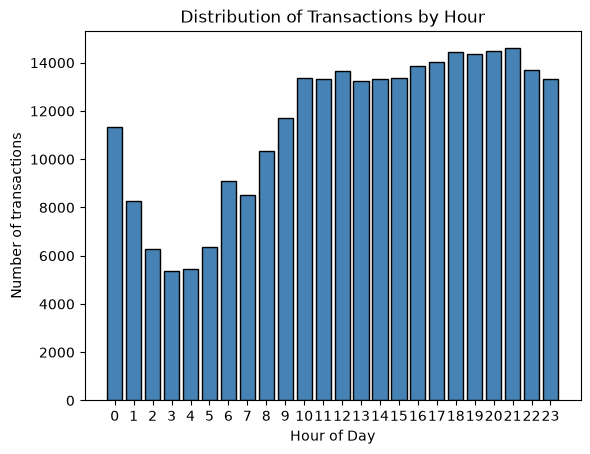

In [25]:
#General  graph of transaction activity tranformed to UTC +0:00
counts, bins, patches = plt.hist(db_final[db_final["is_regional_location"] == 0]["time_adjusted"].dt.hour, bins=np.arange(25), 
                                 rwidth=0.8, color='steelblue', edgecolor='black')

plt.xticks(np.arange(24) + 0.5, labels=range(24))

plt.title("Distribution of Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of transactions")

plt.show()

# Creating aggregated dataset with relative values 

In [26]:
#Extracting only hour of transaction from dataset
db_final["hour"] = pd.to_datetime(db_final["mempool_entry_time"]).dt.hour

In [29]:
#Aggregation of transaction into entities
pivot = (
    db_final.pivot_table(
        index=["entity", "offset", "is_regional_location"],
        columns="hour",
        values="txid",
        aggfunc="count",
        fill_value=0
    )
)

In [30]:
pivot.head()

,,hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
entity,offset,is_regional_location,,,,,,,,,,,,,,,,,,,,,,,,
Entity 100,7.0,0,4,8,5,11,11,13,7,12,11,10,10,16,8,7,12,12,14,26,8,3,2,3,0,2
Entity 1000,2.0,0,5,5,3,1,0,1,2,0,1,1,4,1,2,2,0,0,0,1,0,1,0,1,0,1
Entity 1001,2.0,0,1,1,2,2,3,3,5,9,2,1,1,1,0,2,0,0,0,1,0,0,0,0,0,0
Entity 1002,-5.0,0,2,3,0,0,0,0,0,0,0,0,0,0,1,1,2,3,6,1,2,0,3,2,1,5
Entity 1003,7.0,0,0,0,1,1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [31]:
table = pivot.reset_index()
table.columns.name = None
table.head()

,entity,offset,is_regional_location,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,Entity 100,7.0,0,4,8,5,11,11,13,7,12,11,10,10,16,8,7,12,12,14,26,8,3,2,3,0,2
1,Entity 1000,2.0,0,5,5,3,1,0,1,2,0,1,1,4,1,2,2,0,0,0,1,0,1,0,1,0,1
2,Entity 1001,2.0,0,1,1,2,2,3,3,5,9,2,1,1,1,0,2,0,0,0,1,0,0,0,0,0,0
3,Entity 1002,-5.0,0,2,3,0,0,0,0,0,0,0,0,0,0,1,1,2,3,6,1,2,0,3,2,1,5
4,Entity 1003,7.0,0,0,0,1,1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [32]:
len(table)

4680

In [33]:
cols_to_sum = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
table["total"] = table[cols_to_sum].sum(axis = 1)
table["log_total"] = table["total"].apply(lambda r: np.log(r))

#Bayesian normalization of data 
alpha = 1
table[cols_to_sum] = (table[cols_to_sum] + alpha).div(table["total"] + 24*alpha, axis = 0)

In [34]:
#Finding the middle of the 5 hour minimum inactivity window and the % value of this window
hourly_data = table[cols_to_sum]
circular_data = pd.concat([hourly_data, hourly_data.iloc[:,:4]], axis = 1)
rolling_sums = circular_data.T.rolling(window=5).sum().T
hours = (rolling_sums.iloc[:, 4:].idxmin(axis=1).astype(int) - 2)%24
table["min_5h_activity"] = hours
table["min_5h_activity_sin"] = np.sin(hours*np.pi/12)
table["min_5h_activity_cos"] = np.cos(hours*np.pi/12)
table["min_5h_activity_%"] = rolling_sums.iloc[:, 4:].min(axis=1)



In [35]:
#Adding lifespan of entity in days
lifespan_df = db_final.groupby('entity').agg(
    first_tx=('mempool_entry_time', 'min'),
    last_tx=('mempool_entry_time', 'max')
).reset_index()
lifespan_df['lifespan_days'] = (lifespan_df['last_tx'] - lifespan_df['first_tx']).dt.total_seconds() / 86400
table = table.merge(lifespan_df[["entity", "lifespan_days"]], how = "left", on = "entity")

In [36]:
#Adding week days and weekend activity
db_final["day_type"] = np.where(db_final["mempool_entry_time"].dt.dayofweek < 5, "weekday", "weekend")
db_final.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset,is_regional_location,time_adjusted,hour,day_type
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605,Entity 1861,Europe/Copenhagen,1.0,0,2020-09-06 04:41:07,3,weekend
1,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.298024,Entity 505,Asia/Manila,8.0,0,2015-11-26 21:20:49,13,weekday
3,00007bf94d53e5a2cfb4d7aa94039553fadd80f85b9b5eca57de2bd986d56e2e,0,188FPxXv1i4d9F7jQUYUf1Zt2RTh7RnFCG,2016-05-15 20:19:07,34.793774,1,2,0.285407,Entity 70,Europe/Kyiv,2.0,0,2016-05-15 22:19:07,20,weekend
4,0000a1407c1f573268ea82a20305ed68294351a1f665d08544c3900987df3c43,0,1NissionTGS4S8DvNmGf13amLQuWUZM1nd,2017-08-17 00:59:42,389.105058,1,2,0.107424,Entity 2090,Asia/Tokyo,9.0,0,2017-08-17 09:59:42,0,weekday
5,0000dec5df278bdb99d2c1763ddbfe93114651e2d87269a1d6ee3065682da921,0,36mskh4wzSgYCXUNae61VF98HrXrjGYdRr,2016-07-27 19:45:25,149.700599,1,2,53.317689,Entity 106,Europe/Stockholm,1.0,0,2016-07-27 20:45:25,19,weekday


In [37]:
table_weekday_weekend = (
    db_final.pivot_table(
        index=["entity", "offset", "day_type"],
        columns="hour",
        values="txid",
        aggfunc="count",
        fill_value=0
    )
)
table_weekday_weekend = table_weekday_weekend.reset_index()

cols_to_sum = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
table_weekday_weekend["total"] = table_weekday_weekend[cols_to_sum].sum(axis = 1)
table_weekday_weekend["log_total"] = table_weekday_weekend["total"].apply(lambda r: np.log(r))

#Bayesian normalization of data 
alpha = 1
table_weekday_weekend[cols_to_sum] = (table_weekday_weekend[cols_to_sum] + alpha).div(table_weekday_weekend["total"] + 24*alpha, axis = 0)

df_unstacked = table_weekday_weekend.set_index(['entity', 'offset', 'day_type']).unstack('day_type')
df_unstacked.columns = [f"{str(hour)}_{day}" for hour, day in df_unstacked.columns]
df_wide = df_unstacked.reset_index()
df_wide = df_wide.fillna(0)

In [38]:
table_weekday_weekend.head()

hour,entity,offset,day_type,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,total,log_total
0,Entity 100,7.0,weekday,0.022599,0.050847,0.028249,0.050847,0.067797,0.073446,0.039548,0.045198,0.033898,0.056497,0.050847,0.050847,0.028249,0.022599,0.056497,0.073446,0.084746,0.062147,0.033898,0.022599,0.011299,0.016949,0.005650,0.011299,153,5.030438
1,Entity 100,7.0,weekend,0.023256,0.011628,0.023256,0.046512,0.011628,0.023256,0.023256,0.069767,0.081395,0.023256,0.034884,0.104651,0.058140,0.058140,0.046512,0.011628,0.011628,0.197674,0.046512,0.011628,0.023256,0.023256,0.011628,0.023256,62,4.127134
2,Entity 1000,2.0,weekday,0.100000,0.100000,0.080000,0.040000,0.020000,0.020000,0.040000,0.020000,0.040000,0.040000,0.080000,0.040000,0.060000,0.040000,0.020000,0.020000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,26,3.258097
3,Entity 1000,2.0,weekend,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.033333,0.033333,0.066667,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,6,1.791759
4,Entity 1001,2.0,weekday,0.035714,0.035714,0.035714,0.053571,0.071429,0.071429,0.107143,0.178571,0.053571,0.035714,0.035714,0.035714,0.017857,0.053571,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,32,3.465736


In [39]:
df_wide.head()

,entity,offset,0_weekday,0_weekend,1_weekday,1_weekend,2_weekday,2_weekend,3_weekday,3_weekend,4_weekday,4_weekend,5_weekday,5_weekend,6_weekday,6_weekend,7_weekday,7_weekend,8_weekday,8_weekend,9_weekday,9_weekend,10_weekday,10_weekend,11_weekday,11_weekend,12_weekday,12_weekend,13_weekday,13_weekend,14_weekday,14_weekend,15_weekday,15_weekend,16_weekday,16_weekend,17_weekday,17_weekend,18_weekday,18_weekend,19_weekday,19_weekend,20_weekday,20_weekend,21_weekday,21_weekend,22_weekday,22_weekend,23_weekday,23_weekend,total_weekday,total_weekend,log_total_weekday,log_total_weekend
0,Entity 100,7.0,0.022599,0.023256,0.050847,0.011628,0.028249,0.023256,0.050847,0.046512,0.067797,0.011628,0.073446,0.023256,0.039548,0.023256,0.045198,0.069767,0.033898,0.081395,0.056497,0.023256,0.050847,0.034884,0.050847,0.104651,0.028249,0.058140,0.022599,0.058140,0.056497,0.046512,0.073446,0.011628,0.084746,0.011628,0.062147,0.197674,0.033898,0.046512,0.022599,0.011628,0.011299,0.023256,0.016949,0.023256,0.005650,0.011628,0.011299,0.023256,153.0,62.0,5.030438,4.127134
1,Entity 1000,2.0,0.100000,0.066667,0.100000,0.066667,0.080000,0.033333,0.040000,0.033333,0.020000,0.033333,0.020000,0.066667,0.040000,0.066667,0.020000,0.033333,0.040000,0.033333,0.040000,0.033333,0.080000,0.066667,0.040000,0.033333,0.060000,0.033333,0.040000,0.066667,0.020000,0.033333,0.020000,0.033333,0.020000,0.033333,0.040000,0.033333,0.020000,0.033333,0.040000,0.033333,0.020000,0.033333,0.040000,0.033333,0.020000,0.033333,0.040000,0.033333,26.0,6.0,3.258097,1.791759
2,Entity 1001,2.0,0.035714,0.038462,0.035714,0.038462,0.035714,0.076923,0.053571,0.038462,0.071429,0.038462,0.071429,0.038462,0.107143,0.038462,0.178571,0.038462,0.053571,0.038462,0.035714,0.038462,0.035714,0.038462,0.035714,0.038462,0.017857,0.038462,0.053571,0.038462,0.017857,0.038462,0.017857,0.038462,0.017857,0.038462,0.017857,0.076923,0.017857,0.038462,0.017857,0.038462,0.017857,0.038462,0.017857,0.038462,0.017857,0.038462,0.017857,0.038462,32.0,2.0,3.465736,0.693147
3,Entity 1002,-5.0,0.066667,0.028571,0.066667,0.057143,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.057143,0.022222,0.057143,0.044444,0.057143,0.088889,0.028571,0.133333,0.057143,0.044444,0.028571,0.066667,0.028571,0.022222,0.028571,0.066667,0.057143,0.066667,0.028571,0.022222,0.057143,0.044444,0.142857,21.0,11.0,3.044522,2.397895
4,Entity 1003,7.0,0.034483,0.000000,0.034483,0.000000,0.068966,0.000000,0.068966,0.000000,0.034483,0.000000,0.034483,0.000000,0.137931,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,5.0,0.0,1.609438,0.000000


In [40]:
table = table.merge(df_wide[["entity", 
                             "0_weekday", "1_weekday", "2_weekday", "3_weekday", "4_weekday", "5_weekday", "6_weekday", "7_weekday", "8_weekday", "9_weekday", "10_weekday", "11_weekday", "12_weekday", "13_weekday", "14_weekday", "15_weekday", "16_weekday", "17_weekday", "18_weekday", "19_weekday", "20_weekday", "21_weekday", "22_weekday", "23_weekday",
                             "0_weekend", "1_weekend", "2_weekend", "3_weekend", "4_weekend", "5_weekend", "6_weekend", "7_weekend", "8_weekend", "9_weekend", "10_weekend", "11_weekend", "12_weekend", "13_weekend", "14_weekend", "15_weekend", "16_weekend", "17_weekend", "18_weekend", "19_weekend", "20_weekend", "21_weekend", "22_weekend", "23_weekend",
                             "total_weekday", "total_weekend"]], how = "left", on = "entity")

In [41]:
table.head()

,entity,offset,is_regional_location,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,total,log_total,min_5h_activity,min_5h_activity_sin,min_5h_activity_cos,min_5h_activity_%,lifespan_days,0_weekday,1_weekday,2_weekday,3_weekday,4_weekday,5_weekday,6_weekday,7_weekday,8_weekday,9_weekday,10_weekday,11_weekday,12_weekday,13_weekday,14_weekday,15_weekday,16_weekday,17_weekday,18_weekday,19_weekday,20_weekday,21_weekday,22_weekday,23_weekday,0_weekend,1_weekend,2_weekend,3_weekend,4_weekend,5_weekend,6_weekend,7_weekend,8_weekend,9_weekend,10_weekend,11_weekend,12_weekend,13_weekend,14_weekend,15_weekend,16_weekend,17_weekend,18_weekend,19_weekend,20_weekend,21_weekend,22_weekend,23_weekend,total_weekday,total_weekend
0,Entity 100,7.0,0,0.020921,0.037657,0.025105,0.050209,0.050209,0.058577,0.033473,0.054393,0.050209,0.046025,0.046025,0.071130,0.037657,0.033473,0.054393,0.054393,0.062762,0.112971,0.037657,0.016736,0.012552,0.016736,0.004184,0.012552,215,5.370638,21,-0.707107,0.707107,0.062762,527.561829,0.022599,0.050847,0.028249,0.050847,0.067797,0.073446,0.039548,0.045198,0.033898,0.056497,0.050847,0.050847,0.028249,0.022599,0.056497,0.073446,0.084746,0.062147,0.033898,0.022599,0.011299,0.016949,0.005650,0.011299,0.023256,0.011628,0.023256,0.046512,0.011628,0.023256,0.023256,0.069767,0.081395,0.023256,0.034884,0.104651,0.058140,0.058140,0.046512,0.011628,0.011628,0.197674,0.046512,0.011628,0.023256,0.023256,0.011628,0.023256,153.0,62.0
1,Entity 1000,2.0,0,0.107143,0.107143,0.071429,0.035714,0.017857,0.035714,0.053571,0.017857,0.035714,0.035714,0.089286,0.035714,0.053571,0.053571,0.017857,0.017857,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,32,3.465736,16,-0.866025,-0.500000,0.107143,125.700324,0.100000,0.100000,0.080000,0.040000,0.020000,0.020000,0.040000,0.020000,0.040000,0.040000,0.080000,0.040000,0.060000,0.040000,0.020000,0.020000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.033333,0.033333,0.066667,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,26.0,6.0
2,Entity 1001,2.0,0,0.034483,0.034483,0.051724,0.051724,0.068966,0.068966,0.103448,0.172414,0.051724,0.034483,0.034483,0.034483,0.017241,0.051724,0.017241,0.017241,0.017241,0.034483,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241,34,3.526361,20,-0.866025,0.500000,0.086207,1093.023981,0.035714,0.035714,0.035714,0.053571,0.071429,0.071429,0.107143,0.178571,0.053571,0.035714,0.035714,0.035714,0.017857,0.053571,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.038462,0.038462,0.076923,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.076923,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,32.0,2.0
3,Entity 1002,-5.0,0,0.053571,0.071429,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.035714,0.035714,0.053571,0.071429,0.125000,0.035714,0.053571,0.017857,0.071429,0.053571,0.035714,0.107143,32,3.465736,4,0.866025,0.500000,0.089286,1229.220995,0.066667,0.066667,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.044444,0.088889,0.133333,0.044444,0.066667,0.022222,0.066667,0.066667,0.022222,0.044444,0.028571,0.057143,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.057143,0.057143,0.057143,0.028571,0.057143,0.028571,0.028571,0.028571,0.057143,0.028571,0.057143,0.142857,21.0,11.0
4,Entity 1003,7.0,0,0.034483,0.034483,0.068966,0.068966,0.034483,0.034483,0.137931,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,5,1.609438,9,0.707107,-0.707107,0.172414,818.865532,0.034483,0.034483,0.068966,0.068966,0.034483,

In [42]:
len(table)

4680

In [43]:
table = table[(table["total"] >= 15) & (table["total"] <= 10000)]
len(table)

1934

In [45]:
len(table[table["is_regional_location"] == 1])

255

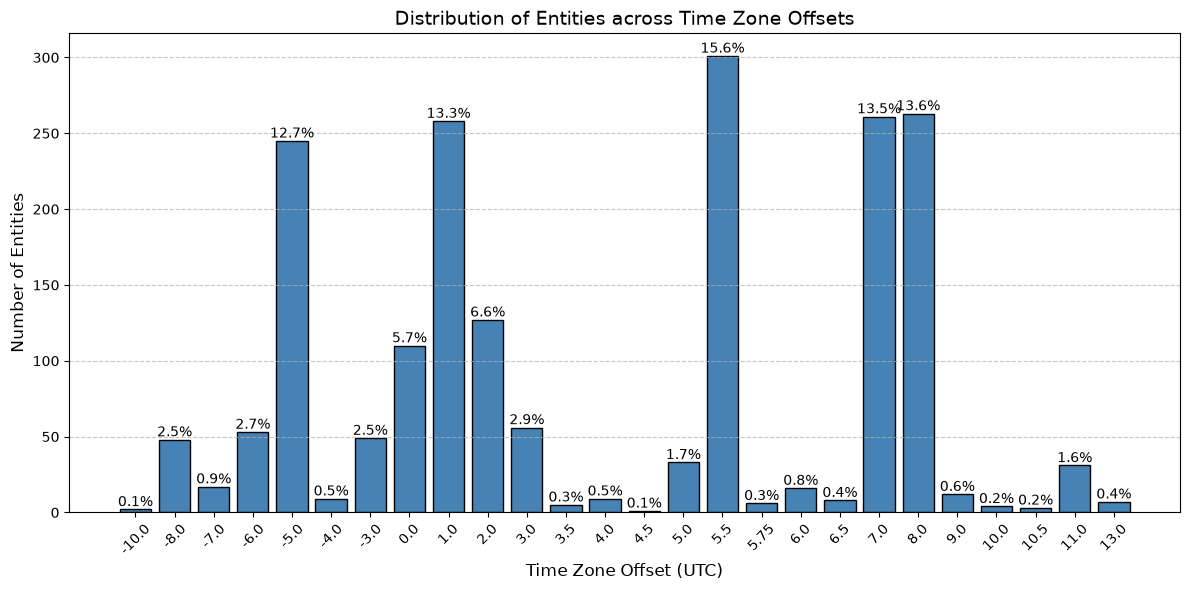

In [44]:
# 1. Count the occurrences of each offset 
offset_counts = table['offset'].value_counts().sort_index()

# Calculate the total number of entities to compute percentages
total_entities = len(table)

# 2. Set up the visualization using subplots for easier annotation control
fig, ax = plt.subplots(figsize=(12, 6))

# Create the bars and store them in a variable
bars = ax.bar(offset_counts.index.astype(str), offset_counts.values, color='steelblue', edgecolor='black')

# 3. Add the percentage labels on top of the columns
for bar in bars:
    count = bar.get_height()
    percentage = (count / total_entities) * 100
    
    # Place the text centered above each bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X position: middle of the bar
        count,                              # Y position: top of the bar
        f'{percentage:.1f}%',               # Text: formatted to 1 decimal place
        ha='center',                        # Horizontally center the text
        va='bottom',                        # Vertically align to the bottom of the text bounding box
        fontsize=10
    )

# 4. Add formatting and labels tailored to the data
plt.title('Distribution of Entities across Time Zone Offsets', fontsize=14)
plt.xlabel('Time Zone Offset (UTC)', fontsize=12)
plt.ylabel('Number of Entities', fontsize=12)

# Rotate the labels slightly in case the offset names get crowded
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Render the graph
plt.tight_layout()
plt.show()

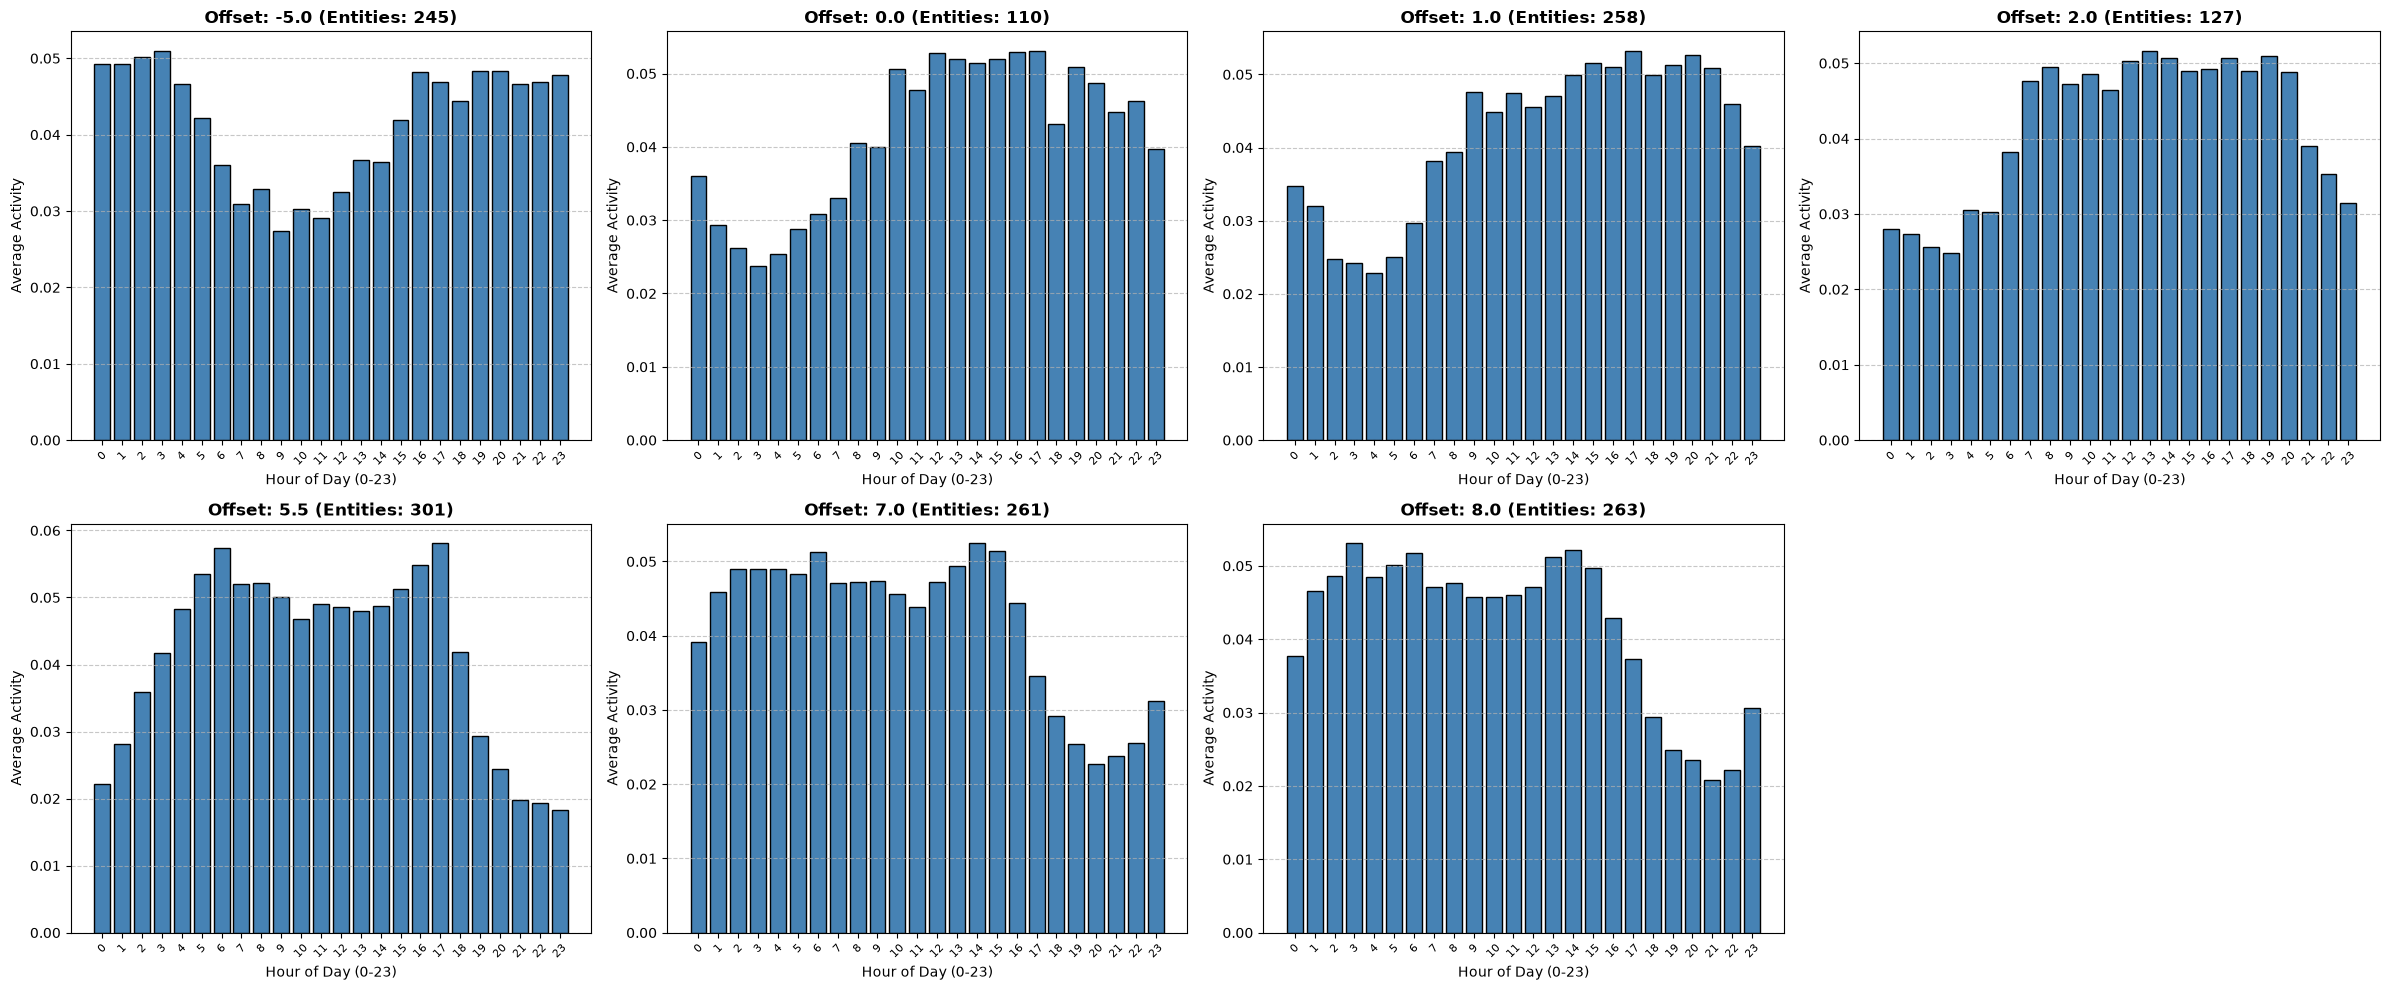

In [45]:
# 1. Find the top 7 largest offsets by entity count, then sort them by the offset value (smallest to largest)
top_7_offsets = table['offset'].value_counts().nlargest(7).sort_index()

# 2. Identify the hour columns (0 to 23)
activity_cols = [col for col in table.columns if str(col).isdigit() and 0 <= int(col) <= 23]
activity_cols = sorted(activity_cols, key=lambda x: int(x))

# 3. Create a single figure with a 2x4 grid (2 rows, 4 columns)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten() # Flatten the 2D array of axes for easier looping

# 4. Loop through the sorted top 7 offsets and plot their average activity
for i, (offset_val, count) in enumerate(top_7_offsets.items()):
    ax = axes[i]
    
    # Filter data for the current offset
    subset = table[table['offset'] == offset_val]
    
    # Calculate the AVERAGE (mean) across the 0-23 columns
    avg_activity = subset[activity_cols].mean()
    
    # Plot as a bar chart to show the distribution
    ax.bar(avg_activity.index.astype(str), avg_activity.values, color='steelblue', edgecolor='black')
    
    # Add title with the offset value and the exact number of entities
    ax.set_title(f'Offset: {offset_val} (Entities: {count})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hour of Day (0-23)', fontsize=10)
    ax.set_ylabel('Average Activity', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Rotate x-axis labels to ensure they fit nicely in a 4-column layout
    ax.tick_params(axis='x', rotation=45, labelsize=8)

# 5. Hide the 8th (unused) subplot since we only need 7 graphs
axes[7].set_visible(False)

# 6. Adjust spacing and render
plt.tight_layout()
plt.show()

# Creating regions

In [46]:
#Mapping and grouping data by defined regions
region_mapping = {
    # America
    -8.0: 'America', -7.0: 'America', -6.0: 'America', -5.0: 'America', -4.0: 'America', -3.0: 'America',
    
    # Euro-Africa
    0.0: 'Euro_Africa', 1.0: 'Euro_Africa', 2.0: 'Euro_Africa', 3.0: 'Euro_Africa',
    
    # Central Asia / India / Middle East
    3.5: 'Central_South_Asia', 4.0: 'Central_South_Asia', 4.5: 'Central_South_Asia', 5.0: 'Central_South_Asia', 
    5.5: 'Central_South_Asia', 5.75: 'Central_South_Asia', 6.0: 'Central_South_Asia', 6.5: 'Central_South_Asia',
    
    # East Asia / Pacific
    7.0: 'East_Asia_Pac', 8.0: 'East_Asia_Pac', 9.0: 'East_Asia_Pac', 10.0: 'East_Asia_Pac', 10.5: 'East_Asia_Pac', 11.0: 'East_Asia_Pac', 
    12.0: 'East_Asia_Pac', 13.0: 'East_Asia_Pac', -10.0: 'East_Asia_Pac', -9.0: 'East_Asia_Pac'
}

table['region'] = table['offset'].map(region_mapping)

In [47]:
table.head()

,entity,offset,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,total,log_total,min_5h_activity,min_5h_activity_sin,min_5h_activity_cos,min_5h_activity_%,lifespan_days,0_weekday,1_weekday,2_weekday,3_weekday,4_weekday,5_weekday,6_weekday,7_weekday,8_weekday,9_weekday,10_weekday,11_weekday,12_weekday,13_weekday,14_weekday,15_weekday,16_weekday,17_weekday,18_weekday,19_weekday,20_weekday,21_weekday,22_weekday,23_weekday,0_weekend,1_weekend,2_weekend,3_weekend,4_weekend,5_weekend,6_weekend,7_weekend,8_weekend,9_weekend,10_weekend,11_weekend,12_weekend,13_weekend,14_weekend,15_weekend,16_weekend,17_weekend,18_weekend,19_weekend,20_weekend,21_weekend,22_weekend,23_weekend,total_weekday,total_weekend,region
0,Entity 100,7.0,0.020921,0.037657,0.025105,0.050209,0.050209,0.058577,0.033473,0.054393,0.050209,0.046025,0.046025,0.071130,0.037657,0.033473,0.054393,0.054393,0.062762,0.112971,0.037657,0.016736,0.012552,0.016736,0.004184,0.012552,215,5.370638,21,-0.707107,0.707107,0.062762,527.561829,0.022599,0.050847,0.028249,0.050847,0.067797,0.073446,0.039548,0.045198,0.033898,0.056497,0.050847,0.050847,0.028249,0.022599,0.056497,0.073446,0.084746,0.062147,0.033898,0.022599,0.011299,0.016949,0.005650,0.011299,0.023256,0.011628,0.023256,0.046512,0.011628,0.023256,0.023256,0.069767,0.081395,0.023256,0.034884,0.104651,0.058140,0.058140,0.046512,0.011628,0.011628,0.197674,0.046512,0.011628,0.023256,0.023256,0.011628,0.023256,153.0,62.0,East_Asia_Pac
1,Entity 1000,2.0,0.107143,0.107143,0.071429,0.035714,0.017857,0.035714,0.053571,0.017857,0.035714,0.035714,0.089286,0.035714,0.053571,0.053571,0.017857,0.017857,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,32,3.465736,16,-0.866025,-0.500000,0.107143,125.700324,0.100000,0.100000,0.080000,0.040000,0.020000,0.020000,0.040000,0.020000,0.040000,0.040000,0.080000,0.040000,0.060000,0.040000,0.020000,0.020000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.033333,0.033333,0.066667,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,26.0,6.0,Euro_Africa
2,Entity 1001,2.0,0.034483,0.034483,0.051724,0.051724,0.068966,0.068966,0.103448,0.172414,0.051724,0.034483,0.034483,0.034483,0.017241,0.051724,0.017241,0.017241,0.017241,0.034483,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241,34,3.526361,20,-0.866025,0.500000,0.086207,1093.023981,0.035714,0.035714,0.035714,0.053571,0.071429,0.071429,0.107143,0.178571,0.053571,0.035714,0.035714,0.035714,0.017857,0.053571,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.038462,0.038462,0.076923,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.076923,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,32.0,2.0,Euro_Africa
3,Entity 1002,-5.0,0.053571,0.071429,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.035714,0.035714,0.053571,0.071429,0.125000,0.035714,0.053571,0.017857,0.071429,0.053571,0.035714,0.107143,32,3.465736,4,0.866025,0.500000,0.089286,1229.220995,0.066667,0.066667,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.044444,0.088889,0.133333,0.044444,0.066667,0.022222,0.066667,0.066667,0.022222,0.044444,0.028571,0.057143,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.057143,0.057143,0.057143,0.028571,0.057143,0.028571,0.028571,0.028571,0.057143,0.028571,0.057143,0.142857,21.0,11.0,America
5,Entity 1004,7.0,0.017241,0.017241,0.017241,0.051724,0.086207,0.068966,0.086207,0.051724,0.017241,0.034483,0.086207,0.017241,0.103448,0.051724,0.017241,0.017241,0.051724,0.034483,0.068966,0.017241,0.034483,0.017241,0.017241,0.017241,34,3.526361,23,-0.258819,0.965926,0.086207,431.026157,0.018868,0.018868,0.0

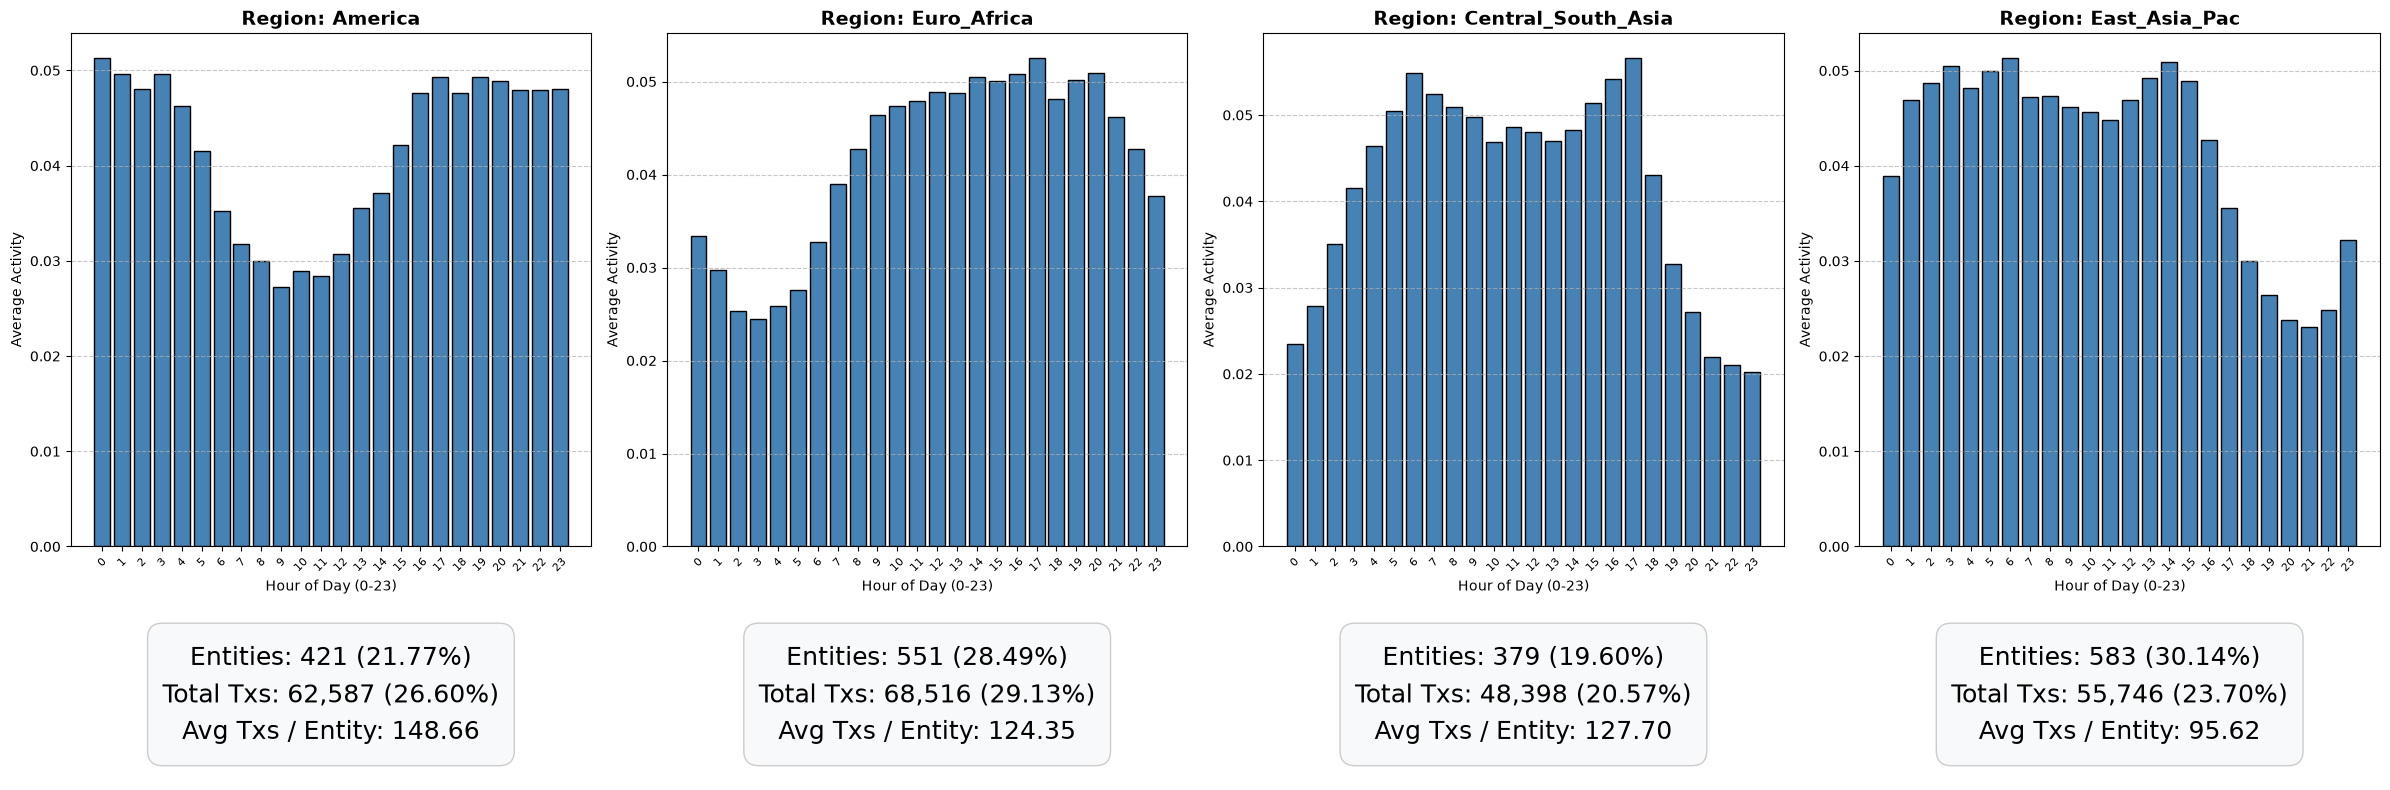

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. DATA PREPARATION & CALCULATIONS
# ---------------------------------------------------------

activity_cols = [col for col in table.columns if str(col).isdigit() and 0 <= int(col) <= 23]
activity_cols = sorted(activity_cols, key=lambda x: int(x))
total_entities_all = len(table)
total_txs_all = table['total'].sum()

summary_table = table.groupby('region').agg(
    number_of_entities=('entity', 'count'),
    number_of_txs=('total', 'sum')
).reset_index()

summary_table['avg_txs_per_entity'] = summary_table['number_of_txs'] / summary_table['number_of_entities']
summary_table['entity_percentage'] = (summary_table['number_of_entities'] / total_entities_all) * 100
summary_table['txs_percentage'] = (summary_table['number_of_txs'] / total_txs_all) * 100

summary_table = summary_table.round({'avg_txs_per_entity': 2, 'entity_percentage': 2, 'txs_percentage': 2})

# ---------------------------------------------------------
# 2. SPECIFY DESIRED REGION ORDER
# ---------------------------------------------------------

desired_order = ['America', 'Euro_Africa', 'Central_South_Asia', 'East_Asia_Pac']

# Filter to ensure only existing regions in the data are processed in order
regions_to_plot = [r for r in desired_order if r in table['region'].values]

# ---------------------------------------------------------
# 3. VISUALIZATION: HISTOGRAMS WITH STATS UNDERNEATH
# ---------------------------------------------------------

# Create 2 rows: Top row for Histograms, Bottom row for Region Stats
fig, axes = plt.subplots(
    nrows=2, 
    ncols=len(regions_to_plot), 
    figsize=(24, 8), 
    gridspec_kw={'height_ratios': [3, 1]}
)

for i, region in enumerate(regions_to_plot):
    ax_chart = axes[0, i]
    ax_stats = axes[1, i]
    
    # Filter data for current region
    subset = table[table['region'] == region]
    avg_activity = subset[activity_cols].mean()
    
    # Get summary statistics row for this region
    reg_stats = summary_table[summary_table['region'] == region].iloc[0]
    
    # --- TOP ROW: Histogram Plot ---
    ax_chart.bar(avg_activity.index.astype(str), avg_activity.values, color='steelblue', edgecolor='black')
    ax_chart.set_title(f'Region: {region}', fontsize=14, fontweight='bold')
    ax_chart.set_xlabel('Hour of Day (0-23)', fontsize=10)
    ax_chart.set_ylabel('Average Activity', fontsize=10)
    ax_chart.grid(axis='y', linestyle='--', alpha=0.7)
    ax_chart.tick_params(axis='x', rotation=45, labelsize=8)
    
    # --- BOTTOM ROW: Region Specific Stats ---
    ax_stats.axis('off')  # Hide axis ticks and box
    
    stats_text = (
        f"Entities: {int(reg_stats['number_of_entities']):,} ({reg_stats['entity_percentage']:.2f}%)\n"
        f"Total Txs: {int(reg_stats['number_of_txs']):,} ({reg_stats['txs_percentage']:.2f}%)\n"
        f"Avg Txs / Entity: {reg_stats['avg_txs_per_entity']:.2f}"
    )
    
    # Add formatted text box directly beneath the corresponding histogram
    ax_stats.text(
        0.5, 0.5, stats_text,
        transform=ax_stats.transAxes,
        fontsize=18,
        ha='center',
        va='center',
        linespacing=1.5,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='#cccccc', linewidth=1)
    )

plt.tight_layout()
plt.show()

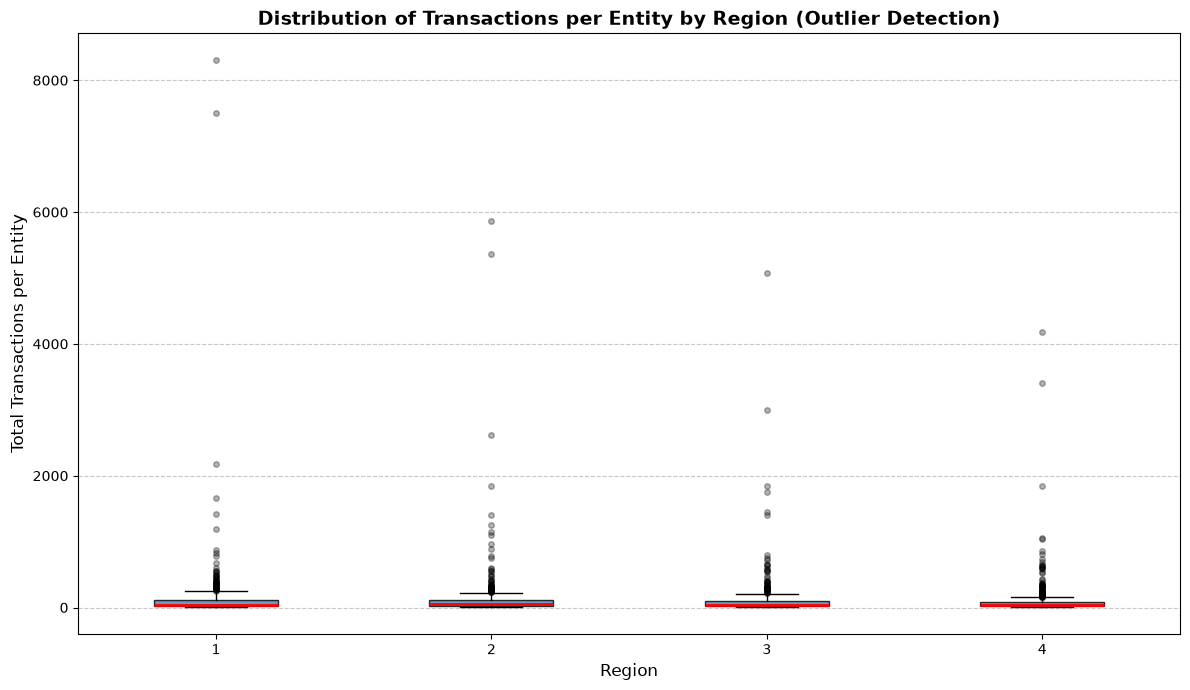

In [49]:
# Ensure we only try to plot regions that actually exist in the dataset
regions_to_plot = [r for r in desired_order if r in table['region'].values]

# Group the transaction data by region into a list of arrays for matplotlib
data_to_plot = [table[table['region'] == region]['total'] for region in regions_to_plot]

# Create the box plot figure
plt.figure(figsize=(12, 7))

# Plot the data
# - patch_artist=True allows us to fill the boxes with color
# - flierprops controls the appearance of the outlier markers (the dots)
plt.boxplot(
    data_to_plot, 
    label=regions_to_plot, 
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='black', alpha=0.8),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='black', markerfacecolor='black', alpha=0.3, markersize=4)
)

# Formatting and labels
plt.title('Distribution of Transactions per Entity by Region (Outlier Detection)', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Transactions per Entity', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ---------------------------------------------------------
# OPTIONAL: LOG SCALE
# If extreme outliers make the main boxes unreadable, 
# uncomment the line below to view the data on a log scale:
# ---------------------------------------------------------
# plt.yscale('log')

plt.tight_layout()
plt.show()

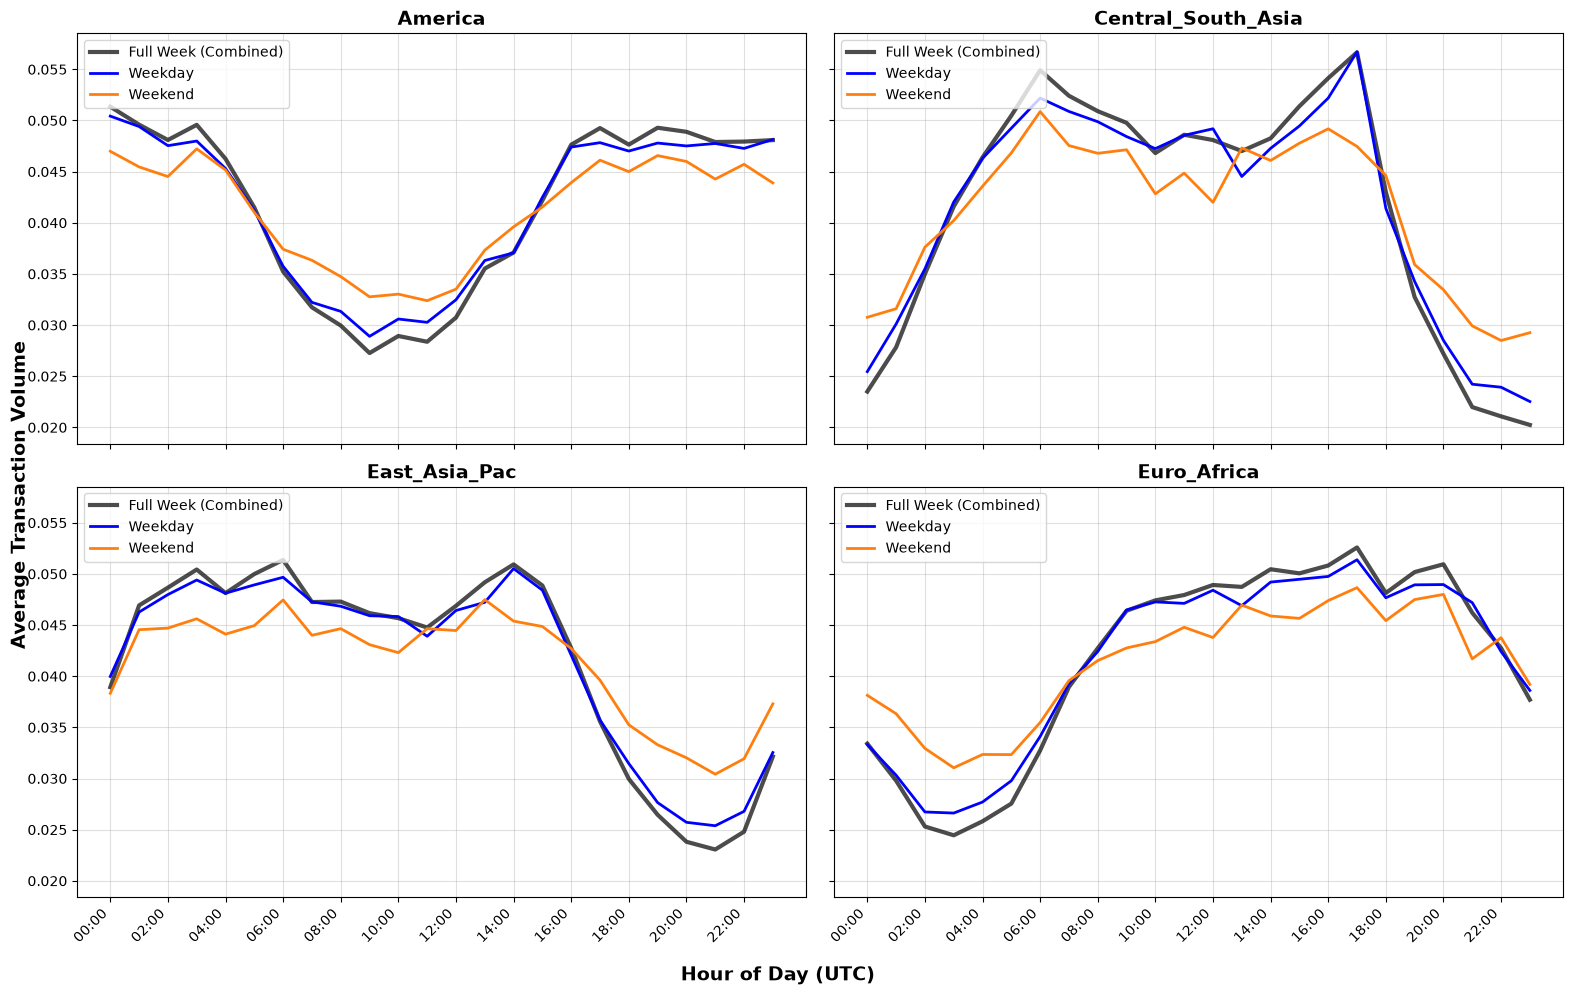

In [50]:
# 1. Group the data by region
table.columns = table.columns.astype(str)  # Ensure all column names are strings for consistency
region_means = table.groupby('region').mean(numeric_only=True)


# 2. Define column names
weekday_cols = [f"{i}_weekday" for i in range(24)]
weekend_cols = [f"{i}_weekend" for i in range(24)]
combined_cols = [f"{i}" for i in range(24)] 

# 3. Create a 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

regions = ["America", "Central_South_Asia", "East_Asia_Pac", "Euro_Africa"]
tick_positions = range(0, 24, 2)
tick_labels = [f"{h:02d}:00" for h in tick_positions]

for i, region in enumerate(regions):
    if region in region_means.index:
        # Extract the specific row of averages for this region
        weekday_data = region_means.loc[region, weekday_cols].values
        weekend_data = region_means.loc[region, weekend_cols].values
        combined_data = region_means.loc[region, combined_cols].values
          
        # Plot the Combined Full Week trend (Thick dark line)
        axes[i].plot(range(24), combined_data, label='Full Week (Combined)', color='black', linewidth=3, alpha=0.7)

        # Plot the separated Weekday and Weekend trends
        axes[i].plot(range(24), weekday_data, label='Weekday', color='blue', linewidth=2)
        axes[i].plot(range(24), weekend_data, label='Weekend', color='#ff7f0e', linewidth=2)
        
        # Formatting
        axes[i].set_title(f"{region}", fontsize=14, fontweight='bold')
        axes[i].set_xticks(tick_positions)
        axes[i].set_xticklabels(tick_labels, rotation=45, ha='right')
        axes[i].grid(True, alpha=0.4)
        axes[i].legend(loc="upper left", fontsize=10)



# 4. Add overarching labels and save
fig.supxlabel("Hour of Day (UTC)", fontsize=14, fontweight='bold')
fig.supylabel("Average Transaction Volume", fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()
plt.close()

In [51]:
table.to_csv("database_from_bitcointalk.csv")